## Fourth Assignment

## Problem 1
1. Produce the kde plot for GRB T90 distribution (refer to the Fermi GBM GRB catalog that was shared earlier) using top hat and gaussian kernels for three different bandwidths which include demonstrating the scenario of under-smoothed, over-smoothed and properly smoothed.  

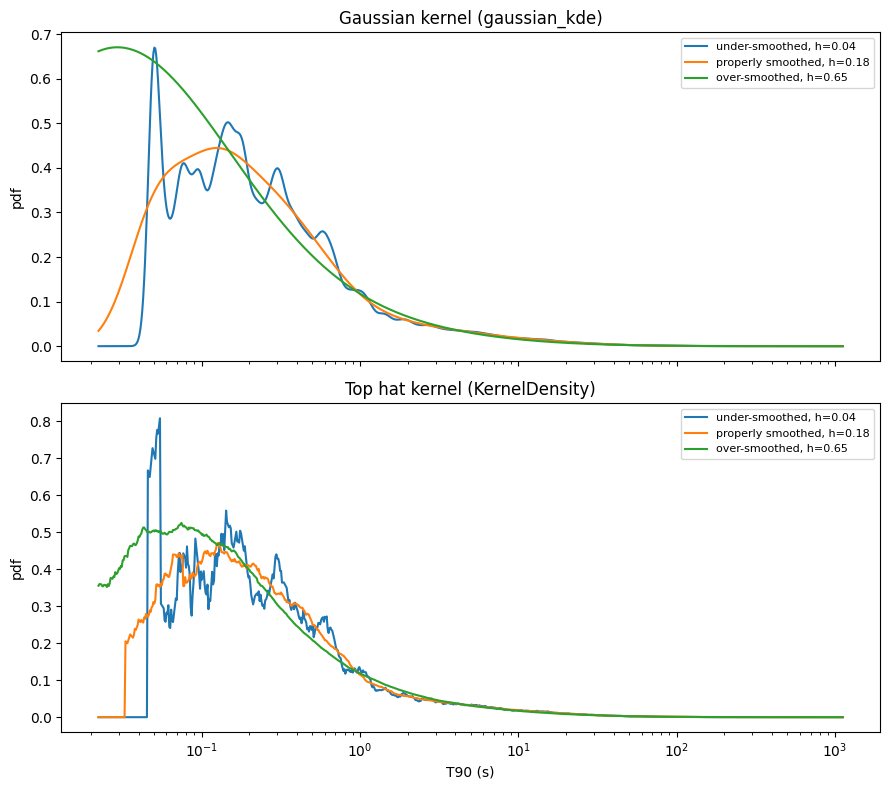

In [5]:
# Problem 1 — Ch.6 KDE: gaussian_kde (Gaussian); top hat only via sklearn (not in scipy)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

catalog = Path.cwd() / "fermigbrst_t90.csv"
if not catalog.exists():
    catalog = Path(r"Fermi_GBM_catalog_15_8_22.txt")

t90_df = pd.read_csv(catalog)
if "T90" in t90_df.columns:
    col = "T90"
else:
    col = t90_df.columns[0]
t90 = t90_df[col].to_numpy(dtype=float)
keep = []
for i in range(len(t90)):
    if np.isfinite(t90[i]) and t90[i] > 0:
        keep.append(t90[i])
t90 = np.array(keep)

u = np.log10(t90)
u_min = float(np.min(u) - 0.35)
u_max = float(np.max(u) + 0.35)
grid_u = np.linspace(u_min, u_max, 800)
T = np.power(10.0, grid_u)
ln10 = np.log(10.0)

labels = ["under-smoothed", "properly smoothed", "over-smoothed"]
hs = [0.04, 0.18, 0.65]

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax = axes[0]
for i in range(3):
    kde_g = gaussian_kde(u, bw_method=hs[i])
    pdf_u = kde_g(np.atleast_2d(grid_u))
    pdf_T = pdf_u / (T * ln10)
    ax.plot(T, pdf_T, label=labels[i] + ", h=" + str(hs[i]))
ax.set_xscale("log")
ax.set_ylabel("pdf")
ax.set_title("Gaussian kernel (gaussian_kde)")
ax.legend(fontsize=8)

u_col = u.reshape(-1, 1)
grid_col = grid_u.reshape(-1, 1)
ax = axes[1]
for i in range(3):
    kde_th = KernelDensity(kernel="tophat", bandwidth=hs[i]).fit(u_col)
    pdf_u = np.exp(kde_th.score_samples(grid_col))
    pdf_T = pdf_u / (T * ln10)
    ax.plot(T, pdf_T, label=labels[i] + ", h=" + str(hs[i]))
ax.set_xscale("log")
ax.set_ylabel("pdf")
ax.set_title("Top hat kernel (KernelDensity)")
ax.legend(fontsize=8)

axes[1].set_xlabel("T90 (s)")
plt.tight_layout()
plt.show()

# Problem 2
2. Use the Savgol filter to produce the smoothed curve of the sample dataset below that consists of the minimum temperatures across the months of the year from the Southern Hemisphere from 1981 to 1990 (data filename: daily-min-temperatures.csv).

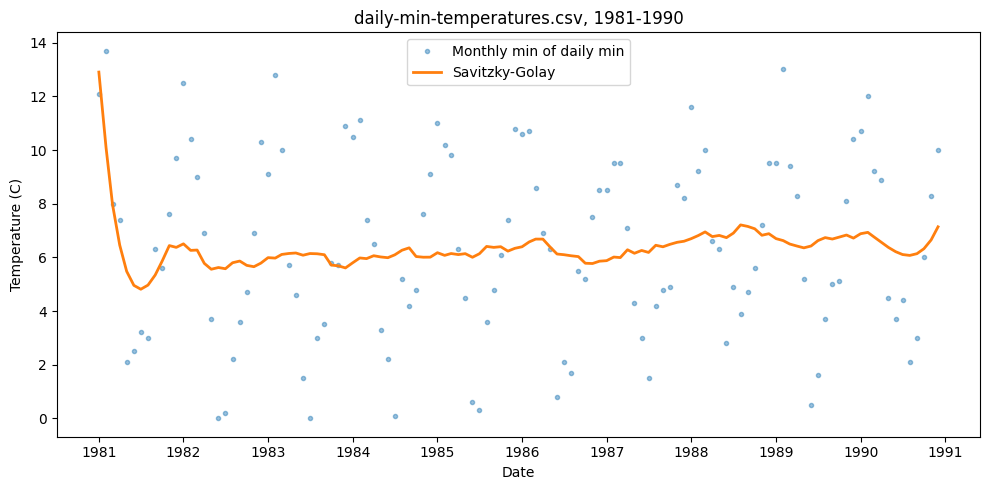

In [1]:
# Problem 2 — Ch.8: scipy.signal.savgol_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter

csv_path = Path(r"C:\Users\RONAK SINGH\Downloads\DataSets (1)\DataSets\daily-min-temperatures.csv")
df = pd.read_csv(csv_path, parse_dates=["Date"])
t_start = pd.Timestamp("1981-01-01")
t_end = pd.Timestamp("1990-12-31")

month_min = {}
for i in range(len(df)):
    d = df["Date"].iloc[i]
    if d < t_start:
        continue
    if d > t_end:
        continue
    temp = df["Temp"].iloc[i]
    key = (d.year, d.month)
    if key not in month_min:
        month_min[key] = temp
    else:
        if temp < month_min[key]:
            month_min[key] = temp

keys_sorted = sorted(month_min.keys())
x_dates = []
y = []
for k in range(len(keys_sorted)):
    key = keys_sorted[k]
    x_dates.append(pd.Timestamp(year=key[0], month=key[1], day=1))
    y.append(month_min[key])
y = np.array(y, dtype=float)

window_length = 21
y_smooth = savgol_filter(y, window_length=window_length, polyorder=3)

plt.figure(figsize=(10, 5))
plt.plot(x_dates, y, ".", alpha=0.45, markersize=6, label="Monthly min of daily min")
plt.plot(x_dates, y_smooth, "-", lw=2, label="Savitzky-Golay")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.title("daily-min-temperatures.csv, 1981-1990")
plt.legend()
plt.tight_layout()
plt.show()

## Problem 3
3. Using the fits data file for the GRB160624477,
(a) Plot the lightcurve of the GRB using an appropriate bin width such that the GRB is visible (has a good signal to noise ratio).
Note: Lightcurve is just the histogram of the TIME column data (available within the fits file).
The Trigger time of the GRB is 488460437.76 s. Please choose the data between -50 s to +50s around the trigger time of the GRB.  

(b) Compare the signal to noise ratio of the GRB detection in three different binwidths: 0.01s, 1s and 10 s.

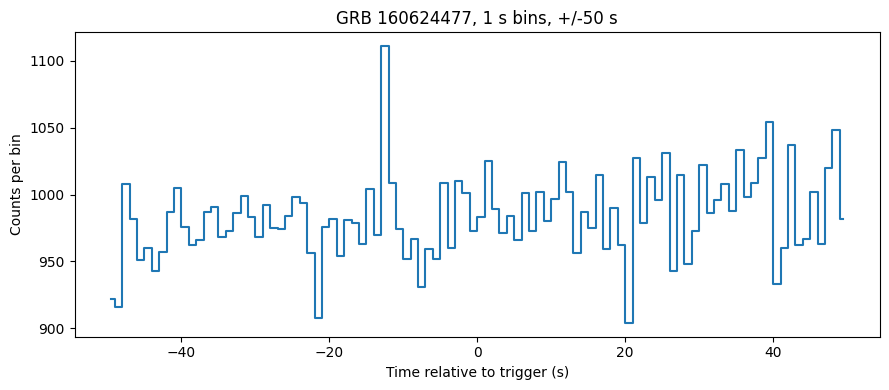

bin width 0.01 s  peak 24.0 mean bg bin 9.844 SNR 4.5118510253472275
bin width 1.0 s  peak 1111.0 mean bg bin 984.4 SNR 4.035040546828114
bin width 10.0 s  peak 10121.0 mean bg bin 9854.25 SNR 2.6871545175656646


In [12]:
# Problem 3 — histogram light curve (Ch.7-style binning); FITS via astropy.io.fits
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

fits_path = Path(r"C:\Users\RONAK SINGH\Downloads\DataSets (1)\DataSets\glg_tte_n2_bn160624477_v00.fit")
trigger = 488460437.76
half_window = 50.0

with fits.open(fits_path) as hdul:
    times = np.asarray(hdul["EVENTS"].data["TIME"], dtype=float)

t_sel_list = []
for j in range(len(times)):
    tr = times[j] - trigger
    if tr < -half_window:
        continue
    if tr > half_window:
        continue
    t_sel_list.append(tr)
t_sel = np.array(t_sel_list, dtype=float)

binw_display = 1.0
bins_a = np.arange(-half_window, half_window + 1e-9, binw_display)
counts_a, edges_a = np.histogram(t_sel, bins=bins_a)
centers_a = 0.5 * (edges_a[:-1] + edges_a[1:])

plt.figure(figsize=(9, 4))
plt.step(centers_a, counts_a, where="mid")
plt.xlabel("Time relative to trigger (s)")
plt.ylabel("Counts per bin")
plt.title("GRB 160624477, 1 s bins, +/-50 s")
plt.tight_layout()
plt.show()

bg_edge = 25.0
bin_widths = [0.01, 1.0, 10.0]
for b in range(len(bin_widths)):
    bw = bin_widths[b]
    bins = np.arange(-half_window, half_window + 1e-9, bw)
    c, edges = np.histogram(t_sel, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    peak = float(c[0])
    for k in range(1, len(c)):
        if c[k] > peak:
            peak = float(c[k])
    s_bg = 0.0
    n_bg = 0
    for k in range(len(c)):
        if abs(centers[k]) > bg_edge:
            s_bg = s_bg + float(c[k])
            n_bg = n_bg + 1
    if n_bg > 0:
        bg_mean = s_bg / n_bg
    else:
        bg_mean = 1.0
    snr = (peak - bg_mean) / np.sqrt(bg_mean + 1e-12)
    print("bin width", bw, "s  peak", peak, "mean bg bin", bg_mean, "SNR", snr)

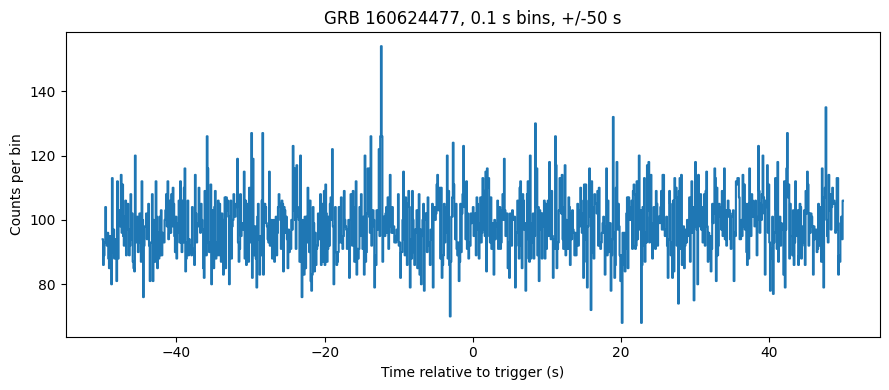

bin width 0.001 s  peak 7.0 mean bg bin 0.9844 SNR 6.063077899245181
bin width 0.1 s  peak 154.0 mean bg bin 98.44 SNR 5.59985052334317
bin width 1.0 s  peak 1111.0 mean bg bin 984.4 SNR 4.035040546828114


In [15]:
# Problem 3 — histogram light curve (Ch.7-style binning); FITS via astropy.io.fits
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

fits_path = Path(r"C:\Users\RONAK SINGH\Downloads\DataSets (1)\DataSets\glg_tte_n2_bn160624477_v00.fit")
trigger = 488460437.76
half_window = 50.0

with fits.open(fits_path) as hdul:
    times = np.asarray(hdul["EVENTS"].data["TIME"], dtype=float)

t_sel_list = []
for j in range(len(times)):
    tr = times[j] - trigger
    if tr < -half_window:
        continue
    if tr > half_window:
        continue
    t_sel_list.append(tr)
t_sel = np.array(t_sel_list, dtype=float)

# Reduced display bin width from 1.0 to 0.1
binw_display = 0.1
bins_a = np.arange(-half_window, half_window + 1e-9, binw_display)
counts_a, edges_a = np.histogram(t_sel, bins=bins_a)
centers_a = 0.5 * (edges_a[:-1] + edges_a[1:])

plt.figure(figsize=(9, 4))
plt.step(centers_a, counts_a, where="mid")
plt.xlabel("Time relative to trigger (s)")
plt.ylabel("Counts per bin")
# Updated title to reflect the new 0.1s bins
plt.title("GRB 160624477, 0.1 s bins, +/-50 s")
plt.tight_layout()
plt.show()

bg_edge = 25.0
# Reduced bin widths to test
bin_widths = [0.001, 0.1, 1.0]
for b in range(len(bin_widths)):
    bw = bin_widths[b]
    bins = np.arange(-half_window, half_window + 1e-9, bw)
    c, edges = np.histogram(t_sel, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    peak = float(c[0])
    for k in range(1, len(c)):
        if c[k] > peak:
            peak = float(c[k])
    s_bg = 0.0
    n_bg = 0
    for k in range(len(c)):
        if abs(centers[k]) > bg_edge:
            s_bg = s_bg + float(c[k])
            n_bg = n_bg + 1
    if n_bg > 0:
        bg_mean = s_bg / n_bg
    else:
        bg_mean = 1.0
    snr = (peak - bg_mean) / np.sqrt(bg_mean + 1e-12)
    print("bin width", bw, "s  peak", peak, "mean bg bin", bg_mean, "SNR", snr)


In [ ]:
# Problem 1 — Ch.6 KDE: gaussian_kde (Gaussian); top hat only via sklearn (not in scipy)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity

catalog = Path.cwd() / "/content/drive/MyDrive/Data analysis course/DataSets/Fermi_GBM_catalog_15_8_22.txt"
if not catalog.exists():
    catalog = Path(r"/content/drive/MyDrive/Data analysis course/DataSets/Fermi_GBM_catalog_15_8_22.txt")

t90_df = pd.read_csv(catalog)
if "T90" in t90_df.columns:
    col = "T90"
else:
    col = t90_df.columns[0]
t90 = t90_df[col].to_numpy(dtype=float)
keep = []
for i in range(len(t90)):
    if np.isfinite(t90[i]) and t90[i] > 0:
        keep.append(t90[i])
t90 = np.array(keep)

u = np.log10(t90)
u_min = float(np.min(u) - 0.35)
u_max = float(np.max(u) + 0.35)
grid_u = np.linspace(u_min, u_max, 800)
T = np.power(10.0, grid_u)
ln10 = np.log(10.0)

labels = ["under-smoothed", "properly smoothed", "over-smoothed"]
hs = [0.04, 0.18, 0.65]

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax = axes[0]
for i in range(3):
    kde_g = gaussian_kde(u, bw_method=hs[i])
    pdf_u = kde_g(np.atleast_2d(grid_u))
    pdf_T = pdf_u / (T * ln10)
    ax.plot(T, pdf_T, label=labels[i] + ", h=" + str(hs[i]))
ax.set_xscale("log")
ax.set_ylabel("pdf")
ax.set_title("Gaussian kernel (gaussian_kde)")
ax.legend(fontsize=8)

u_col = u.reshape(-1, 1)
grid_col = grid_u.reshape(-1, 1)
ax = axes[1]
for i in range(3):
    kde_th = KernelDensity(kernel="tophat", bandwidth=hs[i]).fit(u_col)
    pdf_u = np.exp(kde_th.score_samples(grid_col))
    pdf_T = pdf_u / (T * ln10)
    ax.plot(T, pdf_T, label=labels[i] + ", h=" + str(hs[i]))
ax.set_xscale("log")
ax.set_ylabel("pdf")
ax.set_title("Top hat kernel (KernelDensity)")
ax.legend(fontsize=8)

axes[1].set_xlabel("T90 (s)")
plt.tight_layout()
plt.show()